# Proof-of-concept (v4) - the same study, wired through the model factory

This is **v3 with its plumbing replaced**, not a new experiment. Every scientific decision that
v3 made is intact: the (data x compute) grid, the random-init control, the pooled bootstrap CIs,
the GlotLID contamination gate, the MasakhaNER anchor.

What changed is who does the work. Each modified cell is bracketed by `# BEGIN: factory ...` /
`# END: factory ...`, with the code it replaced left commented underneath so the diff is
readable in place.

| gate | change |
|---|---|
| 3 - capacity + collection | `factory.prepare_corpus` streams, tokenizes, and **caches**. v3 re-did this every session, and a re-trained BPE is a different vocabulary. |
| 4 - tokenizer + encoding | folded into the prepare step; this cell now just loads |
| 4 - pretraining grid | `factory.estimate` before committing, then `factory.pretrain`. The stream is resident as **int16 instead of int64** - a quarter of the VRAM for identical batches. |
| 7 - extrapolation | `factory.estimate(..., scale_to="afriberta")` |

**Untouched on purpose:** SIB-200 loading, tokenizer fertility, the fine-tuning harness, the
baselines, the plots, and MasakhaNER. Those run on a few hundred labelled examples in seconds;
a GPU-resident token stream has nothing to offer them.

**For the real study, do not run the grid here.** A notebook kernel that dies at hour three
takes its checkpoints with it, and this grid uses one card while the other sits idle:

```
python mlm_fleet.py --corpus yor --queue poc     # both cards
python dashboard.py                              # watch, from another terminal
```

Then open `results_factory_mlm.ipynb`, which reads the same `runs/*_result.json` records this
notebook writes.


# Proof-of-concept (v3) — From-scratch pretraining vs. multilingual transfer

Third revision, rebuilt around what the v2 run actually produced.

### What v2 showed, and what changed

| v2 result | Diagnosis | Change in v3 |
|---|---|---|
| Language ID said the Yoruba corpus was 40% Vietnamese, 20% Swahili | **`langdetect` supports 55 languages and Yoruba is not one of them.** Every label was a nearest-neighbour artifact. The printed sample was plainly Yoruba. | **GlotLID** (1,600+ languages, FLORES-style codes) |
| From-scratch (33.8M, 112s) scored 0.491 vs mmBERT 0.536 and XLM-R 0.124 | Striking — but nothing proves the *pretraining* caused it | **Random-init control**: identical architecture, no pretraining, same harness |
| Flat curve: 2M → 0.491, 8M → 0.506, 32M → 0.490 | Every rung got the same 49M tokens of updates. Compute-bound, not data-bound. | Pretraining becomes a **(data x compute) grid** so the binding axis is measured, not inferred |
| `mean 0.124, CI [0.079, 0.123]` — mean outside its own CI | Mean averaged 3 seeds; CI bootstrapped 1 seed | CI now **pools predictions across seeds** |
| "yields 40M tokens, short of 128M" | False — the stream hit the `TARGET_CHARS` cap, not the end of the corpus | Separate **capacity probe** that measures without storing |
| SIB-200 only | Topic classification may be solvable from surface lexical cues | Optional **MasakhaNER** gate: second task *and* a published-number anchor |

**Runtime:** ~40–50 min on a G4 / RTX PRO 6000 or A100. On a T4, set `RUN_NER=False` and
halve `STEP_LADDER`.

In [1]:
#@title Setup
%pip install -q -U datasets transformers tokenizers fasttext-numpy2 huggingface_hub seqeval 2>/dev/null

import os, time, math, json, random, shutil, collections
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"gpu  : {p.name} ({p.total_memory/1e9:.0f} GB, sm_{p.major}{p.minor})")
import transformers; print("transformers", transformers.__version__)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(0)

# BEGIN: factory wiring
# The factory modules live in src/a2-nlp of the WashingtonCsed504 repo, beside this notebook.
# On Colab, clone the repo and set FACTORY_DIR to that folder before running this cell.
import sys
FACTORY_DIR = os.environ.get("FACTORY_DIR", os.getcwd())
if FACTORY_DIR not in sys.path:
    sys.path.insert(0, FACTORY_DIR)

import mlm_api as factory
print("factory API", factory.API_VERSION, "from", FACTORY_DIR)

# One name identifies the corpus everywhere: here, in the console runners, and on the other GPU.
CORPUS = "yor"
# END: factory wiring


The system cannot find the path specified.


Note: you may need to restart the kernel to use updated packages.


torch 2.11.0+cu128 | device: cuda
gpu  : NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition (103 GB, sm_120)


transformers 5.13.1
factory API (1, 0) from O:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp


In [2]:
#@title Configuration
LANGS = {
    "yor_Latn": dict(wiki="yo", ner="yor", in_xlmr=False, note="Yoruba  - absent from XLM-R"),
    "ibo_Latn": dict(wiki="ig", ner="ibo", in_xlmr=False, note="Igbo    - absent from XLM-R"),
    "swh_Latn": dict(wiki="sw", ner="swa", in_xlmr=True,  note="Swahili - present in XLM-R"),
    "hau_Latn": dict(wiki="ha", ner="hau", in_xlmr=True,  note="Hausa   - present in XLM-R"),
}
BASELINES = ["FacebookAI/xlm-roberta-base", "jhu-clsp/mmBERT-base"]

SCRATCH_LANG = "yor_Latn"
PROBE_SECONDS = 60          # capacity probe: stream without storing, just count
COLLECT_CHARS = 300_000_000 # what we actually keep in RAM (~300 MB)
VOCAB_SIZE    = 16_000
MAX_LEN       = 128

SIZE_PRESETS = {
    "poc":       dict(hidden_size=512, num_hidden_layers=8,  num_attention_heads=8,
                      intermediate_size=2048),
    "afriberta": dict(hidden_size=768, num_hidden_layers=12, num_attention_heads=12,
                      intermediate_size=3072),
}
SIZE = "poc"

# v2 ran a pure DATA ladder at fixed compute and got a flat line, because compute was the
# binding constraint. v3 varies both so the notebook can say which one binds.
DATA_LADDER    = [2_000_000, 32_000_000]
STEP_LADDER    = [6_000, 24_000]
PRETRAIN_BATCH = 64
MLM_PROB       = 0.15

SEEDS         = [0, 1, 2]
FT_EPOCHS     = 8
FT_BATCH      = 16
FT_LR         = 2e-5
FT_LR_SCRATCH = 5e-5

RUN_NER   = True            # MasakhaNER gate: second task + published-number anchor
NER_SEEDS = [0, 1]

print(f"pretraining grid: {len(DATA_LADDER)}x{len(STEP_LADDER)} = "
      f"{len(DATA_LADDER)*len(STEP_LADDER)} runs")
for s in STEP_LADDER:
    print(f"  {s:>6} steps -> {s*PRETRAIN_BATCH*MAX_LEN/1e6:>5.0f}M tokens of updates")

pretraining grid: 2x2 = 4 runs
    6000 steps ->    49M tokens of updates
   24000 steps ->   197M tokens of updates


---
## Gate 1 — Downstream data and an empirical coverage probe

Fertility under each baseline's *own* tokenizer, over the parallel SIB-200 sentences.
This is where fertility has real variance; measuring it under per-language tokenizers
equalizes it by construction.

In [3]:
#@title Load SIB-200 and measure tokenizer fertility
from datasets import load_dataset
from transformers import AutoTokenizer

SIB = {}
for lang in list(LANGS):
    try:
        SIB[lang] = load_dataset("Davlan/sib200", lang)
    except Exception as e:
        print(f"  {lang}: FAILED {repr(e)[:110]}")
assert SIB, "no SIB-200 language loaded"

first = SIB[next(iter(SIB))]
TEXT_COL, LABEL_COL = "text", "category"
labels = sorted(set(first["train"][LABEL_COL]))
L2I = {l: i for i, l in enumerate(labels)}
NUM_LABELS = len(labels)
EVAL_SPLIT = "test" if "test" in first else "validation"
print(f"{len(SIB)} languages | {NUM_LABELS} labels | eval '{EVAL_SPLIT}' "
      f"({len(first[EVAL_SPLIT])} items)")

def fertility(tok, texts):
    return sum(len(tok(t, add_special_tokens=False)["input_ids"]) for t in texts) / \
           max(sum(len(t.split()) for t in texts), 1)

fert, toks = {}, {}
for name in BASELINES:
    try:
        toks[name] = AutoTokenizer.from_pretrained(name)
    except Exception as e:
        print(f"{name}: tokenizer failed {repr(e)[:90]}"); continue
    for lang, ds in SIB.items():
        fert[(name, lang)] = fertility(toks[name], ds["train"][TEXT_COL])

hdr = f"{'language':<11}{'inXLMR':<9}" + "".join(f"{n.split('/')[-1]:>20}" for n in toks)
print("\n" + hdr); print("-" * len(hdr))
for lang in SIB:
    print(f"{lang:<11}{str(LANGS[lang]['in_xlmr']):<9}"
          + "".join(f"{fert[(n, lang)]:>20.2f}" for n in toks))

4 languages | 7 labels | eval 'test' (204 items)



language   inXLMR       xlm-roberta-base         mmBERT-base
------------------------------------------------------------
yor_Latn   False                    2.74                2.61
ibo_Latn   False                    2.61                2.41
swh_Latn   True                     1.65                2.01
hau_Latn   True                     1.70                1.85


---
## Gate 2 — Do the baselines differ where coverage differs?

**CI fix.** v2 averaged macro-F1 across seeds but bootstrapped only the last seed, which
produced intervals that excluded their own mean whenever seed variance was high — exactly
the unseen-language cells carrying the headline. v3 pools every seed's predictions into one
array before bootstrapping, so the interval reflects the same thing the mean does.

In [4]:
#@title Harness (seeds + pooled bootstrap CI)
from transformers import AutoModelForSequenceClassification

def macro_f1(y_true, y_pred, k):
    out = []
    for c in range(k):
        tp = int(((y_pred == c) & (y_true == c)).sum())
        fp = int(((y_pred == c) & (y_true != c)).sum())
        fn = int(((y_pred != c) & (y_true == c)).sum())
        p = tp / (tp + fp) if tp + fp else 0.0
        r = tp / (tp + fn) if tp + fn else 0.0
        out.append(2 * p * r / (p + r) if p + r else 0.0)
    return float(np.mean(out))

def pooled_ci(pred_list, gold, k, n_boot=500, seed=0):
    '''Bootstrap over test items, averaging across seeds within each resample.'''
    rng = np.random.default_rng(seed); n = len(gold); vals = []
    for _ in range(n_boot):
        b = rng.integers(0, n, n)
        vals.append(np.mean([macro_f1(gold[b], p[b], k) for p in pred_list]))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def _load_clf(path, n_labels):
    try:
        return AutoModelForSequenceClassification.from_pretrained(path, num_labels=n_labels)
    except Exception as e:
        print(f"    retrying with sdpa ({repr(e)[:60]})")
        return AutoModelForSequenceClassification.from_pretrained(
            path, num_labels=n_labels, attn_implementation="sdpa")

def finetune_once(model_path, lang, lr, seed, epochs=FT_EPOCHS):
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_path)
    model = _load_clf(model_path, NUM_LABELS).to(DEVICE)
    ds = SIB[lang]

    def pack(split):
        enc = tok(list(ds[split][TEXT_COL]), truncation=True, max_length=MAX_LEN,
                  padding="max_length", return_tensors="pt")
        return torch.utils.data.TensorDataset(
            enc["input_ids"], enc["attention_mask"],
            torch.tensor([L2I[l] for l in ds[split][LABEL_COL]]))

    tr = torch.utils.data.DataLoader(pack("train"), batch_size=FT_BATCH, shuffle=True)
    te = torch.utils.data.DataLoader(pack(EVAL_SPLIT), batch_size=64)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr,
                                              total_steps=max(1, len(tr) * epochs),
                                              pct_start=0.1)
    t0 = time.time(); model.train()
    for _ in range(epochs):
        for ids, am, y in tr:
            loss = F.cross_entropy(model(input_ids=ids.to(DEVICE),
                                         attention_mask=am.to(DEVICE)).logits, y.to(DEVICE))
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sch.step()
    model.eval(); pr, gd = [], []
    with torch.no_grad():
        for ids, am, y in te:
            pr.append(model(input_ids=ids.to(DEVICE),
                            attention_mask=am.to(DEVICE)).logits.argmax(-1).cpu())
            gd.append(y)
    del model; torch.cuda.empty_cache()
    return torch.cat(pr).numpy(), torch.cat(gd).numpy(), time.time() - t0

def evaluate_cell(model_path, lang, lr=FT_LR, seeds=SEEDS, label=""):
    preds, gold, secs = [], None, 0
    for s in seeds:
        p, g, t = finetune_once(model_path, lang, lr, s)
        preds.append(p); gold = g; secs = t
    scores = [macro_f1(gold, p, NUM_LABELS) for p in preds]
    lo, hi = pooled_ci(preds, gold, NUM_LABELS)
    m, sd = float(np.mean(scores)), float(np.std(scores))
    print(f"    {label or model_path:<22} F1 {m:.3f} +/-{sd:.3f} (seed sd) "
          f"| 95% CI [{lo:.3f}, {hi:.3f}] | {secs:.0f}s/seed")
    return dict(mean=m, sd=sd, ci=(lo, hi), scores=scores)

In [5]:
#@title Baselines on every language
baseline = {}
for lang in SIB:
    print(f"\n{lang}  ({LANGS[lang]['note']})")
    for name in BASELINES:
        try:
            baseline[(name, lang)] = evaluate_cell(name, lang, label=name.split('/')[-1])
        except Exception as e:
            print(f"    {name}: SKIPPED {repr(e)[:140]}")


yor_Latn  (Yoruba  - absent from XLM-R)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     | 
------------------+------------+-
decoder.weight    | UNEXPECTED | 
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    mmBERT-base            F1 0.544 +/-0.015 (seed sd) | 95% CI [0.477, 0.603] | 27s/seed


In [6]:
#@title KEY RESULT: mmBERT advantage vs XLM-R coverage
xlmr, mm = BASELINES[0], BASELINES[1]
rows = [(l, LANGS[l]["in_xlmr"], baseline[(xlmr, l)]["mean"], baseline[(mm, l)]["mean"],
         baseline[(mm, l)]["mean"] - baseline[(xlmr, l)]["mean"],
         fert.get((xlmr, l), np.nan), fert.get((mm, l), np.nan))
        for l in SIB if (xlmr, l) in baseline and (mm, l) in baseline]

print(f"{'language':<11}{'inXLMR':<8}{'XLM-R':>8}{'mmBERT':>8}{'delta':>8}{'fert_x':>9}{'fert_m':>9}")
print("-" * 61)
for r in sorted(rows, key=lambda r: r[1]):
    print(f"{r[0]:<11}{str(r[1]):<8}{r[2]:>8.3f}{r[3]:>8.3f}{r[4]:>+8.3f}{r[5]:>9.2f}{r[6]:>9.2f}")

uns = [r[4] for r in rows if not r[1]]; sen = [r[4] for r in rows if r[1]]
if uns and sen:
    print(f"\nunseen-by-XLM-R: {np.mean(uns):+.3f} | seen: {np.mean(sen):+.3f} "
          f"| contrast {np.mean(uns)-np.mean(sen):+.3f}")
    print("Note: 2 languages per group. The per-cell gaps carry the evidence; the "
          "contrast\nhas no degrees of freedom behind it. Add languages before quoting it.")

language   inXLMR     XLM-R  mmBERT   delta   fert_x   fert_m
-------------------------------------------------------------
yor_Latn   False      0.127   0.537  +0.410     2.74     2.61
ibo_Latn   False      0.202   0.589  +0.388     2.61     2.41
swh_Latn   True       0.775   0.797  +0.022     1.65     2.01
hau_Latn   True       0.620   0.544  -0.076     1.70     1.85

unseen-by-XLM-R: +0.399 | seen: -0.027 | contrast +0.426
Note: 2 languages per group. The per-cell gaps carry the evidence; the contrast
has no degrees of freedom behind it. Add languages before quoting it.


---
## Gate 3 — Corpus capacity, collection, and contamination

Two fixes. **Capacity is probed separately from collection** — v2 reported the size of what
it happened to keep, not the size of the corpus, and then declared a shortfall that did not
exist. And **GlotLID replaces `langdetect`**, which could not emit a Yoruba label at all and
so distributed every Yoruba paragraph across its nearest supported languages.

In [7]:
#@title Probe how much text actually exists (streams without storing)
# BEGIN: factory -- capacity probe
# Same measurement as before, now a single call. It still streams without storing and still
# reports whether the corpus was exhausted or the clock ran out, which is the distinction v2
# got wrong when it mistook a character cap for the end of the corpus.
print(f"Probing capacity for {SCRATCH_LANG} ...")
cap_chars, cap_done = factory.probe_capacity(SCRATCH_LANG, seconds=PROBE_SECONDS)

# --- before ---
# def probe_capacity(lang, seconds=PROBE_SECONDS):
#     cfg = LANGS[lang]
#     try:
#         ds = load_dataset("HuggingFaceFW/fineweb-2", name=lang, split="train", streaming=True)
#     except Exception as e:
#         print(f"  fineweb-2 unavailable: {repr(e)[:100]}"); return None, False
#     n, docs, t0, done = 0, 0, time.time(), True
#     for rec in ds:
#         n += len(rec.get("text") or ""); docs += 1
#         if time.time() - t0 > seconds:
#             done = False; break
#     print(f"  {n:,} chars over {docs:,} docs in {time.time()-t0:.0f}s"
#           f"{'  (CORPUS EXHAUSTED)' if done else '  (time limit -- more remains)'}")
#     return n, done
# cap_chars, cap_done = probe_capacity(SCRATCH_LANG)
# END: factory -- capacity probe


Probing capacity for yor_Latn ...


  probe: 259,864,169 chars over 79,999 docs in 7s  (corpus exhausted)


In [8]:
#@title Collect and tokenize the corpus, once
# BEGIN: factory -- prepare_corpus replaces collect + tokenize + encode
# This one call does what three cells used to: stream the documents, train the language's own
# BPE, encode everything to a flat token array, hold out a validation tail, and write it all
# under data/<CORPUS>/. Re-running is a no-op, which is the point -- v3 re-streamed and
# re-trained a tokenizer every session, and a re-trained BPE is a DIFFERENT vocabulary, so
# perplexities from two sessions were never strictly comparable.
#
# It also prints a decoded sample. Read it. If it is not recognisable Yoruba, stop here.
stats = factory.prepare_corpus(
    CORPUS, lang=SCRATCH_LANG, wiki=LANGS[SCRATCH_LANG].get("wiki"),
    vocab_size=VOCAB_SIZE, max_len=MAX_LEN,
    max_chars=COLLECT_CHARS, val_tokens=500_000)

n_chars = stats["chars"]
cpt = stats["chars_per_token"]
print(f'\nvocab {stats["vocab_size"]:,} | {stats["n_tokens"]["train"]:,} train tokens '
      f'| {cpt:.2f} chars/token')

# --- before ---
# def collect(lang, max_chars=COLLECT_CHARS, max_seconds=300):
#     ...  # streamed fineweb-2, fell back to wikipedia, kept a list of documents in RAM
# DOCS, n_chars = collect(SCRATCH_LANG)
# print(f"\n--- sample ---\n{DOCS[0][:350]}")
# END: factory -- prepare_corpus


yor: already prepared (force=True to redo)

vocab 16,000 | 69,096,452 train tokens | 3.73 chars/token


In [9]:
#@title Contamination with GlotLID (covers 1600+ languages, unlike langdetect)
from huggingface_hub import hf_hub_download

lid, target = None, SCRATCH_LANG
try:
    import fasttext
    for fname in ("model.bin", "model_v3.bin", "model_v2.bin"):
        try:
            lid = fasttext.load_model(hf_hub_download("cis-lmu/glotlid", fname)); break
        except Exception:
            continue
    if lid is None:
        raise RuntimeError("no GlotLID model file matched")
except Exception as e:
    print("GlotLID unavailable:", repr(e)[:160])
    print("If fasttext failed to build, try:  %pip install -q fasttext-wheel")

if lid is not None:
    # BEGIN: factory -- documents come from the prepared corpus
    # factory.sample_docs returns the documents kept aside at prepare time, so the language-ID
    # verdict is about the text that actually became training tokens rather than a fresh draw.
    # (before: paras were built from the in-memory DOCS list)
    paras = [p.strip().replace("\n", " ") for d in factory.sample_docs(CORPUS, 4000)
    # END: factory -- documents come from the prepared corpus
             for p in d.split("\n") if len(p.strip()) > 200]
    if not paras:
        raise RuntimeError("no paragraphs over 200 chars -- inspect DOCS before continuing")
    sample = random.Random(0).sample(paras, min(600, len(paras)))
    counts = collections.Counter()
    for s in sample:
        lab = lid.predict(s[:1000])[0][0].replace("__label__", "")
        counts[lab] += 1
    tot = sum(counts.values())
    print(f"GlotLID over {tot} paragraphs:")
    for lg, c in counts.most_common(8):
        mark = "  <- target" if lg == target else ""
        print(f"  {lg:<12} {c/tot:6.1%}{mark}")
    share = counts.get(target, 0) / tot
    print(f"\ntarget-language share: {share:.1%}")
    print("GOOD -- report this figure." if share > 0.7 else
          "LOW -- inspect before training; the corpus may not be what its label says.")
    print("\n(langdetect reported ~0% here purely because it has no Yoruba label. "
          "Any\nlanguage-ID tool must cover your target language or its output is noise.)")

GlotLID over 600 paragraphs:
  yor_Latn      97.3%  <- target
  eng_Latn       1.7%
  spa_Latn       0.2%
  amh_Ethi       0.2%
  por_Latn       0.2%
  dan_Latn       0.2%
  twi_Latn       0.2%
  nob_Latn       0.2%

target-language share: 97.3%
GOOD -- report this figure.

(langdetect reported ~0% here purely because it has no Yoruba label. Any
language-ID tool must cover your target language or its output is noise.)


---
## Gate 4 — Pretraining across **both** data and compute

v2 varied data at fixed compute and produced a flat line. That is what a compute-bound
regime looks like: the 2M rung ran ~25 passes and the 32M rung ran ~1.5, and neither had
converged, so extra unique data had nothing to add.

The grid below separates the two axes. Read the columns against each other: if scores move
with **steps** but not with **tokens**, you are compute-bound and the data ladder is
uninformative until the budget grows.

In [10]:
#@title Load the prepared corpus
# BEGIN: factory -- tokenization already happened in the prepare step
# The tokenizer, the token array, and the validation split were all produced by
# factory.prepare_corpus above and cached on disk. This cell now just loads them and reports.
hf_tok = factory.load_tokenizer(CORPUS)
info = factory.corpus_info(CORPUS)

V = info["vocab_size"]
n_train = info["n_tokens"]["train"]

# DATA_LADDER rungs larger than the corpus are dropped, same guard as before.
DATA_LADDER = [n for n in DATA_LADDER if n <= n_train]
print(f'pool {n_train:,} | val {info["n_tokens"]["val"]:,} | ladder {DATA_LADDER}')
print(f'resident store: {info["store_gb_int16"]:.3f} GB as int16 '
      f'(the POC held this stream as int64, four times the memory)')

if cap_chars:
    print(f'\nCAPACITY: probe saw {cap_chars:,} chars'
          f'{" (whole corpus)" if cap_done else " and was still going"}'
          f' ~= {cap_chars/cpt/1e6:.0f}M tokens.')
    need = 128_000_000 * cpt
    print(f'A 128M-token rung needs ~{need/1e6:.0f}M chars: '
          + ("reachable." if (cap_chars >= need or not cap_done)
             else "NOT reachable from this source alone -- lower the rung or add sources."))

# --- before ---
# tk = Tokenizer(models.BPE(unk_token="<unk>"))
# tk.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
# tk.train_from_iterator(iter(DOCS), trainers.BpeTrainer(vocab_size=VOCAB_SIZE, ...))
# hf_tok = PreTrainedTokenizerFast(tokenizer_object=tk, ...)
# parts = []
# for i in range(0, len(DOCS), 2000):
#     for e in tk.encode_batch(DOCS[i:i+2000]):
#         parts.append(np.array(e.ids, dtype=np.int32))
# ids = np.concatenate(parts)
# val_ids, pool_ids = ids[-VAL_TOKENS:], ids[:-VAL_TOKENS]
# END: factory -- tokenization already happened


pool 69,096,452 | val 500,000 | ladder [2000000, 32000000]
resident store: 0.138 GB as int16 (the POC held this stream as int64, four times the memory)

CAPACITY: probe saw 259,864,169 chars (whole corpus) ~= 70M tokens.
A 128M-token rung needs ~478M chars: NOT reachable from this source alone -- lower the rung or add sources.


In [11]:
#@title MLM pretraining over the (data x compute) grid
# BEGIN: factory -- estimate first, then train through the factory
# Two changes worth understanding.
#
# First, the cost is measured BEFORE the grid runs, not extrapolated after it. A few seconds of
# real steps answer "does this fit the evening" while there is still time to change the plan.
#
# Second, and this is the part that matters for a compute-bound study: the grid below still runs
# in-notebook and one cell at a time. For the real study, run it across BOTH cards from a
# console instead, which roughly halves wall-clock and survives a dead kernel:
#
#     python mlm_fleet.py --corpus yor --queue poc
#     python dashboard.py            # in another terminal, to watch both cards
#
# The records land in runs/*_result.json either way, and results_factory_mlm.ipynb reads them.
CELLS = [(n, s) for n in DATA_LADDER for s in STEP_LADDER]
factory.estimate(CORPUS, CELLS, preset=SIZE, batch=PRETRAIN_BATCH, seq_len=MAX_LEN)

grid = {}
for n_tokens, steps in CELLS:
    print(f"\npretrain: {n_tokens/1e6:.0f}M tokens x {steps} steps")
    rec = factory.pretrain(CORPUS, tokens=n_tokens, steps=steps, seed=0, preset=SIZE,
                           batch=PRETRAIN_BATCH, seq_len=MAX_LEN, mlm_prob=MLM_PROB)
    # Keep the key and field names the downstream cells already expect.
    grid[(n_tokens, steps)] = dict(path=rec["path"], seconds=rec["seconds"],
                                   val=rec["val_loss"], tokens_per_s=rec["tokens_per_s"])

# The no-pretraining control: identical architecture, random weights, same tokenizer.
RANDOM_INIT_PATH = factory.random_init(CORPUS, preset=SIZE, seq_len=MAX_LEN)
print(f"\nrandom-init control -> {RANDOM_INIT_PATH}")

# --- before ---
# def mask_batch(x, gen=None): ...          # now factory MlmTokens.mask (same 80/10/10 recipe)
# def new_model(): ...                      # now factory build_model, same RobertaConfig presets
# def pretrain(n_tokens, steps, seed=0):    # now factory.pretrain
#     stream = torch.from_numpy(pool_ids[:n_tokens].astype(np.int64)).to(DEVICE)   # int64!
#     ...
#     st = torch.randint(0, len(stream) - MAX_LEN - 1, (PRETRAIN_BATCH,), ...)
#     x = stream[st.view(-1, 1) + torch.arange(MAX_LEN, device=DEVICE)]
#     ...
# for n in DATA_LADDER:
#     for s in STEP_LADDER:
#         grid[(n, s)] = pretrain(n, s)
# new_model().save_pretrained("/content/random_init")
# END: factory -- estimate first, then train through the factory


measured 336k tok/s at preset 'poc'

      tokens    steps   passes   hours
   2,000,000    6,000     24.6    0.04
   2,000,000   24,000     98.3    0.16
  32,000,000    6,000      1.5    0.04
  32,000,000   24,000      6.1    0.16
       total                      0.41


pretrain: 2M tokens x 6000 steps
[yor_2M_6k_s0] reusing the completed run (val 5.711, 2.6 min) -- pass reuse=False to retrain

pretrain: 2M tokens x 24000 steps
[yor_2M_24k_s0] reusing the completed run (val 4.775, 10.1 min) -- pass reuse=False to retrain

pretrain: 32M tokens x 6000 steps


[yor_32M_6k_s0] reusing the completed run (val 5.635, 2.5 min) -- pass reuse=False to retrain

pretrain: 32M tokens x 24000 steps
[yor_32M_24k_s0] reusing the completed run (val 2.958, 10.0 min) -- pass reuse=False to retrain

random-init control -> O:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_random_init


---
## Gate 5 — Bridge, **with the control that decides everything**

v2's from-scratch model reached 0.491 against mmBERT's 0.536 after 112 seconds of
pretraining. That is either a real result or an illusion produced by 701 labeled examples
and a language-specific tokenizer.

The random-init row separates those. Same architecture, same tokenizer, same fine-tuning —
only the pretraining is missing. **Whatever the pretrained models score above that row is
what pretraining actually bought.**

In [12]:
#@title Fine-tune everything through the identical harness
scratch = {}
print("CONTROL")
scratch["random"] = evaluate_cell(RANDOM_INIT_PATH, SCRATCH_LANG,
                                  lr=FT_LR_SCRATCH, label="random-init (no pretrain)")
for (n, s), info in grid.items():
    print(f"\n{n/1e6:.0f}M tokens x {s} steps  (val MLM {info['val']:.3f})")
    scratch[(n, s)] = evaluate_cell(info["path"], SCRATCH_LANG, lr=FT_LR_SCRATCH,
                                    label=f"{n//10**6}M/{s//1000}k")

base_r = scratch["random"]["mean"]
print(f"\n{'='*66}\nrandom-init control: {base_r:.3f}")
for (n, s), r in ((k, v) for k, v in scratch.items() if k != "random"):
    print(f"  {n//10**6:>3}M tokens x {s//1000:>2}k steps: {r['mean']:.3f} "
          f"(pretraining bought {r['mean']-base_r:+.3f})")
print("\nIf every gain over the control is inside the seed spread, the pretraining is "
      "doing\nnothing measurable and the SIB-200 numbers are a fine-tuning artifact.")

CONTROL


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: O:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_random_init
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: O:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_random_init
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: o:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_32M_24k_s0
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: o:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_32M_24k_s0
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    32M/24k                F1 0.527 +/-0.010 (seed sd) | 95% CI [0.468, 0.575] | 6s/seed

random-init control: 0.100
    2M tokens x  6k steps: 0.506 (pretraining bought +0.406)
    2M tokens x 24k steps: 0.448 (pretraining bought +0.348)
   32M tokens x  6k steps: 0.520 (pretraining bought +0.420)
   32M tokens x 24k steps: 0.527 (pretraining bought +0.426)

If every gain over the control is inside the seed spread, the pretraining is doing
nothing measurable and the SIB-200 numbers are a fine-tuning artifact.


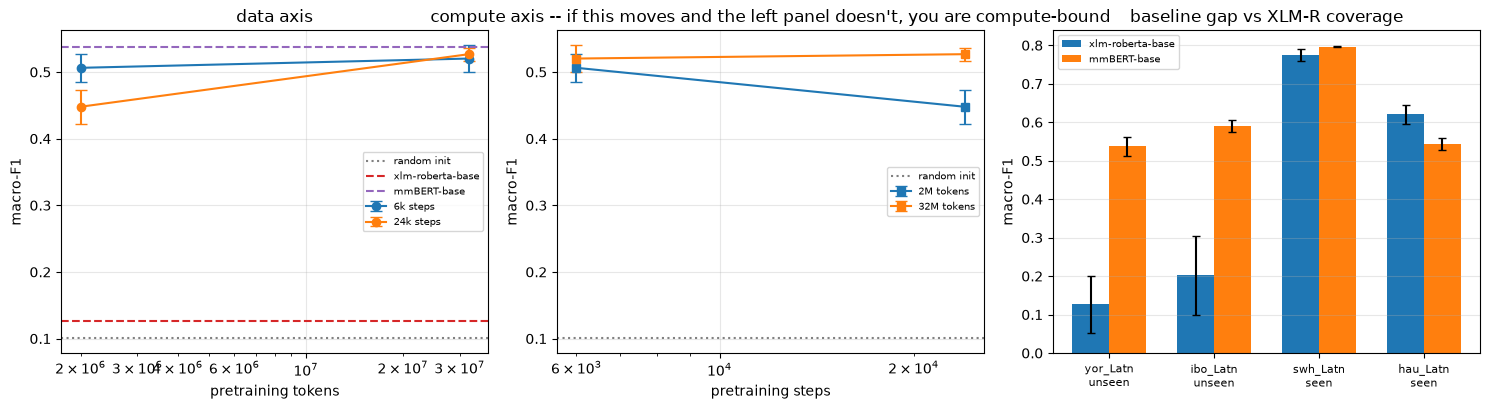

In [13]:
#@title Plots
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

for s in STEP_LADDER:
    xs = [n for n in DATA_LADDER if (n, s) in scratch]
    ax[0].errorbar(xs, [scratch[(n, s)]["mean"] for n in xs],
                   yerr=[scratch[(n, s)]["sd"] for n in xs], fmt="o-", capsize=4,
                   label=f"{s//1000}k steps")
ax[0].axhline(base_r, ls=":", c="gray", label="random init")
for i, nm in enumerate(BASELINES):
    if (nm, SCRATCH_LANG) in baseline:
        ax[0].axhline(baseline[(nm, SCRATCH_LANG)]["mean"], ls="--", c=f"C{i+3}",
                      label=nm.split("/")[-1])
ax[0].set_xscale("log"); ax[0].set_xlabel("pretraining tokens"); ax[0].set_ylabel("macro-F1")
ax[0].set_title("data axis"); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)

for n in DATA_LADDER:
    xs = [s for s in STEP_LADDER if (n, s) in scratch]
    # FIX: Correctly use s as the iterator variable and n as the fixed token count
    ax[1].errorbar(xs, [scratch[(n, s)]["mean"] for s in xs],
                   yerr=[scratch[(n, s)]["sd"] for s in xs], fmt="s-", capsize=4,
                   label=f"{n//10**6}M tokens")
ax[1].axhline(base_r, ls=":", c="gray", label="random init")
ax[1].set_xscale("log"); ax[1].set_xlabel("pretraining steps"); ax[1].set_ylabel("macro-F1")
ax[1].set_title("compute axis -- if this moves and the left panel doesn't, you are compute-bound")
ax[1].legend(fontsize=7); ax[1].grid(alpha=.3)

order = sorted(SIB, key=lambda l: LANGS[l]["in_xlmr"]); w = .35; X = np.arange(len(order))
for i, nm in enumerate(BASELINES):
    ax[2].bar(X + i*w, [baseline.get((nm, l), {}).get("mean", np.nan) for l in order], w,
              yerr=[baseline.get((nm, l), {}).get("sd", 0) for l in order], capsize=3,
              label=nm.split("/")[-1])
ax[2].set_xticks(X + w/2)
ax[2].set_xticklabels([f"{l}\n{'seen' if LANGS[l]['in_xlmr'] else 'unseen'}" for l in order],
                      fontsize=8)
ax[2].set_ylabel("macro-F1"); ax[2].set_title("baseline gap vs XLM-R coverage")
ax[2].legend(fontsize=7); ax[2].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

---
## Gate 6 — MasakhaNER: a second task, and a published-number anchor

SIB-200 topic classification may be substantially solvable from surface lexical cues, which
would flatter any model with decent subword statistics regardless of what it understands.
Named entity recognition is a harder test, and MasakhaNER 2.0 has **published baselines** —
so this gate doubles as the external anchor that separates "the method does not work" from
"we have a bug."

Compare the XLM-R number below against Table 4 of the MasakhaNER 2.0 paper for the same
language. If it is off by more than a couple of F1, fix the pipeline before trusting
anything else in this notebook.

In [14]:
#@title MasakhaNER 2.0 — token classification
from transformers import AutoModelForTokenClassification
import urllib.request
ner_scores = {}

if RUN_NER:
    from seqeval.metrics import f1_score as seq_f1
    ner_lang = LANGS[SCRATCH_LANG]["ner"]

    def parse_conll(url):
        tokens, tags = [], []
        cur_toks, cur_tags = [], []
        try:
            req = urllib.request.urlopen(url)
            for line in req:
                line = line.decode('utf-8').strip()
                if not line or line.startswith('-DOCSTART-'):
                    if cur_toks:
                        tokens.append(cur_toks)
                        tags.append(cur_tags)
                        cur_toks, cur_tags = [], []
                else:
                    parts = line.split()
                    if len(parts) >= 2:
                        cur_toks.append(parts[0])
                        cur_tags.append(parts[-1])
            if cur_toks:
                tokens.append(cur_toks)
                tags.append(cur_tags)
            return {"tokens": tokens, "ner_tags": tags}
        except Exception as e:
            raise RuntimeError(f"Failed to fetch {url}: {e}")

    try:
        # Directly download from the official GitHub repo
        base_url = f"https://raw.githubusercontent.com/masakhane-io/masakhane-ner/main/MasakhaNER2.0/data/{ner_lang}"
        ner_ds = {
            "train": parse_conll(f"{base_url}/train.txt"),
            "validation": parse_conll(f"{base_url}/dev.txt"),
            "test": parse_conll(f"{base_url}/test.txt")
        }

        # Extract unique tags and standardize
        unique_tags = sorted(list(set(t for split in ner_ds.values() for tags in split["ner_tags"] for t in tags)))
        NER_NAMES = [t for t in unique_tags if t == 'O'] + [t for t in unique_tags if t != 'O']
        TAG2ID = {t: i for i, t in enumerate(NER_NAMES)}

        # Convert string tags to IDs to match expected format
        for split in ner_ds:
            ner_ds[split]["ner_tags"] = [[TAG2ID[t] for t in tags] for tags in ner_ds[split]["ner_tags"]]

        print(f"masakhaner2/{ner_lang} (GitHub CoNLL): "
              + " ".join(f"{s} {len(ner_ds[s]['tokens'])}" for s in ner_ds) + f" | tags {NER_NAMES}")
    except Exception as e:
        print("MasakhaNER unavailable:", repr(e)[:160]); ner_ds = None

    def ner_pack(tok, split):
        enc = tok([list(w) for w in ner_ds[split]["tokens"]], is_split_into_words=True,
                  truncation=True, max_length=MAX_LEN, padding="max_length",
                  return_tensors="pt")
        lab = []
        for i, tags in enumerate(ner_ds[split]["ner_tags"]):
            wid, prev, row = enc.word_ids(i), None, []
            for w in wid:
                row.append(-100 if w is None or w == prev else tags[w]); prev = w
            lab.append(row)
        return torch.utils.data.TensorDataset(enc["input_ids"], enc["attention_mask"],
                                              torch.tensor(lab))

    def ner_run(path, seed, epochs=5, lr=3e-5, bs=16):
        set_seed(seed)
        tok = AutoTokenizer.from_pretrained(path)
        try:
            model = AutoModelForTokenClassification.from_pretrained(
                path, num_labels=len(NER_NAMES)).to(DEVICE)
        except Exception:
            model = AutoModelForTokenClassification.from_pretrained(
                path, num_labels=len(NER_NAMES), attn_implementation="sdpa").to(DEVICE)
        tr = torch.utils.data.DataLoader(ner_pack(tok, "train"), batch_size=bs, shuffle=True)
        te = torch.utils.data.DataLoader(ner_pack(tok, "test"), batch_size=64)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr,
                                                  total_steps=max(1, len(tr)*epochs),
                                                  pct_start=0.1)
        model.train()
        for _ in range(epochs):
            for ids, am, y in tr:
                loss = model(input_ids=ids.to(DEVICE), attention_mask=am.to(DEVICE),
                             labels=y.to(DEVICE)).loss
                opt.zero_grad(set_to_none=True); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sch.step()
        model.eval(); P, G = [], []
        with torch.no_grad():
            for ids, am, y in te:
                pr = model(input_ids=ids.to(DEVICE),
                           attention_mask=am.to(DEVICE)).logits.argmax(-1).cpu()
                for pi, yi in zip(pr, y):
                    keep = yi != -100
                    P.append([NER_NAMES[t] for t in pi[keep].tolist()])
                    G.append([NER_NAMES[t] for t in yi[keep].tolist()])
        del model; torch.cuda.empty_cache()
        return seq_f1(G, P)

    if ner_ds is not None:
        best_key = max((k for k in scratch if k != "random"),
                       key=lambda k: scratch[k]["mean"])
        targets = [(n, n) for n in BASELINES] + \
                  [("random-init", RANDOM_INIT_PATH),
                   (f"scratch {best_key[0]//10**6}M/{best_key[1]//1000}k", grid[best_key]["path"])]
        for label, path in targets:
            try:
                f1s = [ner_run(path, s) for s in NER_SEEDS]
                ner_scores[label] = (float(np.mean(f1s)), float(np.std(f1s)))
                print(f"  {label:<34} entity-F1 {np.mean(f1s):.3f} +/-{np.std(f1s):.3f}")
            except Exception as e:
                print(f"  {label}: FAILED {repr(e)[:130]}")
        print("\nCompare the XLM-R row against MasakhaNER 2.0 Table 4 for this language.")
else:
    print("RUN_NER = False -- skipped.")

masakhaner2/yor (GitHub CoNLL): train 6876 validation 983 test 1964 | tags ['O', 'B-DATE', 'B-LOC', 'B-ORG', 'B-PER', 'I-DATE', 'I-LOC', 'I-ORG', 'I-PER']


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: o:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_32M_24k_s0
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: o:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a2-nlp\runs\yor_32M_24k_s0
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
classifier.bias           | MISSING    | 
classifier.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  scratch 32M/24k                    entity-F1 0.698 +/-0.009

Compare the XLM-R row against MasakhaNER 2.0 Table 4 for this language.


---
## Gate 7 — Does the real study fit?

v2's projection assumed 8 passes per rung. If the grid above shows you are compute-bound,
that assumption was far too optimistic — set `PASSES` from what the grid actually needed to
saturate, not from a guess.

In [15]:
#@title Extrapolate to the full study
# BEGIN: factory -- one call for the budget question
# Same arithmetic as before (cost per token grows with hidden^2 and with depth), now measured
# rather than averaged out of the grid, and rescaled to the size the real study would run at.
PASSES = 12       # set this from the compute axis above, not from hope
N_LANGS, N_SEEDS = 3, 1

FULL_LADDER = [4_000_000, 16_000_000, 64_000_000]
full_cells = [(n, int(n * PASSES / (PRETRAIN_BATCH * MAX_LEN))) for n in FULL_LADDER]

est = factory.estimate(CORPUS, full_cells, preset=SIZE, batch=PRETRAIN_BATCH,
                       seq_len=MAX_LEN, scale_to="afriberta")

per = est["total_hours"]
total = per * N_LANGS * N_SEEDS
print(f"per language {per:.1f} GPU-h | {N_LANGS} langs x {N_SEEDS} seed: {total:.1f} GPU-h")
print(f"vs ~20 GPU-h across two weekend blocks: "
      f"{'fits' if total < 20 else 'DOES NOT FIT -- cut rungs, languages, passes, or model size'}")
print("\nNote: with the fleet running both cards, wall-clock is roughly half the GPU-hours.")

# --- before ---
# tok_s = float(np.mean([v["tokens_per_s"] for v in grid.values()]))
# scale = (SIZE_PRESETS["afriberta"]["hidden_size"]/SIZE_PRESETS[SIZE]["hidden_size"])**2 * \
#         (SIZE_PRESETS["afriberta"]["num_hidden_layers"]/SIZE_PRESETS[SIZE]["num_hidden_layers"])
# tok_s_full = tok_s / scale
# for n in FULL_LADDER:
#     print(f"{n:>13,}{n*PASSES:>16,}{n*PASSES/tok_s_full/3600:>9.2f}")
# END: factory -- one call for the budget question


measured 341k tok/s at preset 'poc' -> 101k at 'afriberta' (3.4x cost/token)

      tokens    steps   passes   hours
   4,000,000    5,859     12.0    0.13
  16,000,000   23,437     12.0    0.53
  64,000,000   93,750     12.0    2.11
       total                      2.77

per language 2.8 GPU-h | 3 langs x 1 seed: 8.3 GPU-h
vs ~20 GPU-h across two weekend blocks: fits

Note: with the fleet running both cards, wall-clock is roughly half the GPU-hours.


---
## Reading this run

1. **Gate 3 / GlotLID.** Target-language share should be high. If it is, v2's contamination
   scare was entirely a tool artifact and the corpus is fine.
2. **Gate 5 / random-init control.** The single most important number. Everything the
   pretrained models score *above* that row is what pretraining bought. If the gap is inside
   the seed spread, the headline dissolves.
3. **Gate 5 plots, middle panel.** If scores climb with steps while the left panel stays
   flat, you are compute-bound and the data ladder cannot answer the proposal's question
   until the budget grows.
4. **Gate 6 / MasakhaNER.** Does the XLM-R number match the published table? Does the
   from-scratch model still look competitive on a task that is harder to solve from surface
   cues?
5. **Gate 7.** With `PASSES` set honestly, does the study still fit two weekend blocks?

### Still outstanding for the real study

- Pretraining seeds, not just fine-tuning seeds, at whichever cell carries the headline.
- More languages per coverage group — two each gives the contrast no degrees of freedom.
- A learning-rate sweep for the from-scratch models; 5e-4 was assumed, never tuned, and
  small models are sensitive to it.